dept_id building avg_wait_min peak_patients_per_hr
D1 North 15 120
D2 North 12 95
D3 East 18 140
D4 South 20 110
D5 East 10 160
D6 South 25 90
D7 West 14 105
D8 North 11 130

Part A — Graph Construction
1. Build a graph where departments are nodes. Connect two departments if they are in the
same building.
2. How many edges are there in the graph?
3. Which department has the highest degree?
4. Verify the handshake theorem on this graph.
5. Compute the shortest path between D1 and D7.
Part B — Graph Properties
6. Calculate the degree centrality of each department.
7. Compute the eccentricity of all nodes. Identify the center and periphery of the graph.
8. Draw the graph and visually highlight central vs peripheral departments.
Part C — Machine Learning Hub Prediction
9. Define a label: center = 1 if a department’s degree ≥ 75th percentile, else center = 0 . Print the
updated dataset.
11. Train a Decision Tree Classifier to predict the center.
12. Report accuracy, precision, and recall.

In [ ]:
dept_id building avg_wait_min peak_patients_per_hr
D1 North 15 120
D2 North 12 95
D3 East 18 140
D4 South 20 110
D5 East 10 160
D6 South 25 90
D7 West 14 105
D8 North 11 130

Part A — Graph Construction
1. Build a graph where departments are nodes. Connect two departments if they are in the
same building.
2. How many edges are there in the graph?
3. Which department has the highest degree?
4. Verify the handshake theorem on this graph.
5. Compute the shortest path between D1 and D7.
Part B — Graph Properties
6. Calculate the degree centrality of each department.
7. Compute the eccentricity of all nodes. Identify the center and periphery of the graph.
8. Draw the graph and visually highlight central vs peripheral departments.
Part C — Machine Learning Hub Prediction
9. Define a label: center = 1 if a department’s degree ≥ 75th percentile, else center = 0 . Print the
updated dataset.
11. Train a Decision Tree Classifier to predict the center.
12. Report accuracy, precision, and recall.

Part A — Graph Construction
1. Build a graph where departments are nodes. Connect two departments if they are in the
same building.
2. How many edges are there in the graph?
3. Which department has the highest degree?
4. Verify the handshake theorem on this graph.
5. Compute the shortest path between D1 and D7.

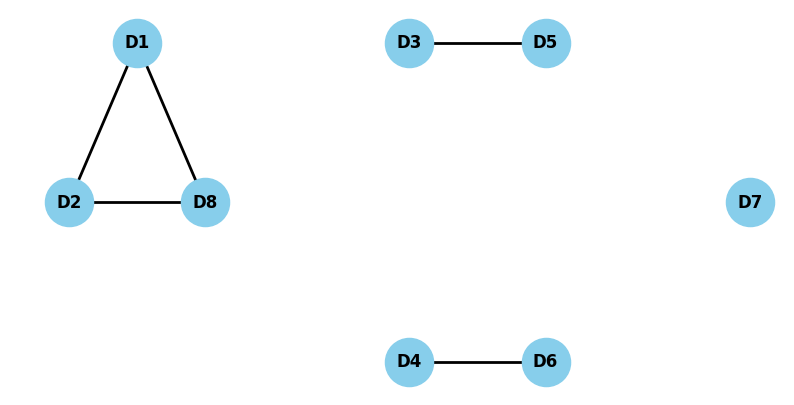

In [21]:
#1. Build a graph where departments are nodes. Connect two departments if they are in the same building

import networkx as nx
import matplotlib.pyplot as plt

# Create Graph
G = nx.Graph()

# Add Nodes
departments = ["D1","D2","D3","D4","D5","D6","D7","D8"]
G.add_nodes_from(departments)

# Add Edges
G.add_edges_from([
    ("D1","D2"),
    ("D1","D8"),
    ("D2","D8"),
    ("D3","D5"),
    ("D4","D6")
])
# Fixed Positions

pos = {

    "D1": (0,2),

    "D2": (-1,1),

    "D8": (1,1),



    "D3": (4,2),

    "D5": (6,2),



    "D4": (4,0),

    "D6": (6,0),



    "D7": (9,1)

}


plt.figure(figsize=(10,5))

nx.draw_networkx_nodes(G, pos, node_color="skyblue", node_size=1200)
nx.draw_networkx_labels(G, pos, font_weight="bold")
nx.draw_networkx_edges(G, pos, edge_color="black", width=2)

plt.axis("off")
plt.show()

In [22]:
# 2. How many edges are there in the graph?
print("Number of edges:", G.number_of_edges())

Number of edges: 5


In [23]:
#3. Which department has the highest degree?
for node in G.nodes():
    print(node, G.degree(node))

D1 2
D2 2
D3 1
D4 1
D5 1
D6 1
D7 0
D8 2


In [24]:
#4. Verify the handshake theorem on this graph.
degree_sum = sum(dict(G.degree()).values())
edges = G.number_of_edges()

print("Sum of Degrees =", degree_sum)
print("2 x Edges =", 2 * edges)

Sum of Degrees = 10
2 x Edges = 10


In [25]:
#5. Compute the shortest path between D1 and D7.
try:
    print(nx.shortest_path(G, "D1", "D7"))
except:
    print("No path exists")

No path exists


Final Answers
Graph Edges: (D1,D2), (D1,D8), (D2,D8), (D3,D5), (D4,D6)
Total Edges: 5
Highest Degree: 2 (Departments D1, D2, D8)
Handshake Theorem: ∑deg(v)=10=2×5, তাই theorem verified।
Shortest Path (D1 → D7): No path exists, কারণ D7 একটি isolated node।

Part B — Graph Properties
6. Calculate the degree centrality of each department.
7. Compute the eccentricity of all nodes. Identify the center and periphery of the graph.
8. Draw the graph and visually highlight central vs peripheral departments.


In [26]:
# 6. Calculate the degree centrality of each department.
dc = nx.degree_centrality(G)

print(dc)

{'D1': 0.2857142857142857, 'D2': 0.2857142857142857, 'D3': 0.14285714285714285, 'D4': 0.14285714285714285, 'D5': 0.14285714285714285, 'D6': 0.14285714285714285, 'D7': 0.0, 'D8': 0.2857142857142857}


In [27]:
#7. Compute the eccentricity of all nodes. Identify the center and periphery of the graph.
H = G.subgraph(["D1","D2","D8"])

print(nx.eccentricity(H))
print(nx.center(H))
print(nx.periphery(H))

{'D2': 1, 'D8': 1, 'D1': 1}
['D2', 'D8', 'D1']
['D2', 'D8', 'D1']


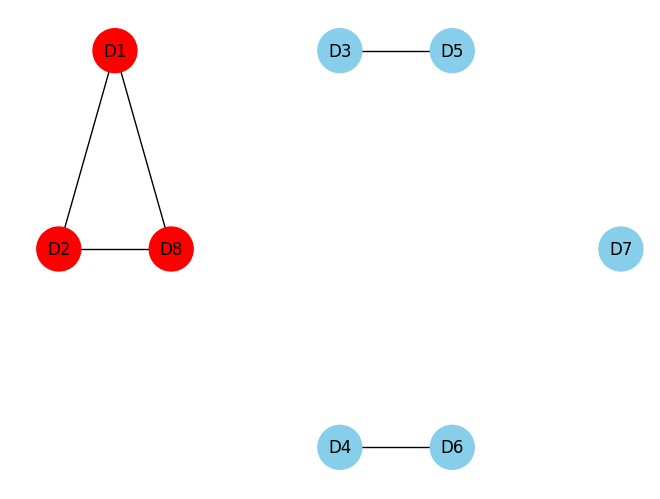

In [28]:
#8. Draw the graph and visually highlight central vs peripheral departments.
colors = []

for node in G.nodes():
    if node in ["D1","D2","D8"]:
        colors.append("red")
    else:
        colors.append("skyblue")

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=colors,
    node_size=1000
)

plt.show()

Part C — Machine Learning Hub Prediction
9. Define a label: center = 1 if a department’s degree ≥ 75th percentile, else center = 0 . Print the
updated dataset.
11. Train a Decision Tree Classifier to predict the center.
12. Report accuracy, precision, and recall.

In [38]:
#9. Define a label: center = 1 if a department’s degree ≥ 75th percentile, else center = 0 . Print the updated dataset

degree = dict(G.degree())
df["degree"] = df["dept_id"].map(degree)
df["center"] = (df["degree"] >= df["degree"].quantile(0.75)).astype(int)
print(df)

  dept_id building  avg_wait_min  peak_patients_per_hr  degree  center
0      D1    North            15                   120       2       1
1      D2    North            12                    95       2       1
2      D3     East            18                   140       1       0
3      D4    South            20                   110       1       0
4      D5     East            10                   160       1       0
5      D6    South            25                    90       1       0
6      D7     West            14                   105       0       0
7      D8    North            11                   130       2       1


In [36]:
#11. Train a Decision Tree Classifier to predict the center.
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
X = df[["avg_wait_min","peak_patients_per_hr"]]
y = df["center"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [37]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))

Accuracy : 0.5
Precision: 0.0
Recall : 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
